# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
campaign_summary = (
    'According to the Materials and Methods section, the data represents 17 direct-marketing '
    'campaigns conducted by a Portuguese bank between May 2008 and November 2010. The '
    'working dataset used in this notebook, bank-additional-full.csv, contains 41,188 '
    'records.'
)

campaign_summary


'According to the Materials and Methods section, the data represents 17 direct-marketing campaigns conducted by a Portuguese bank between May 2008 and November 2010. The working dataset used in this notebook, bank-additional-full.csv, contains 41,188 records.'

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



Let's explore the data types. missing values, special values and also unknown values in the dataset to understand how to handle these before modeling.

In [5]:
categorical_cols = df.select_dtypes(include=['string']).columns.drop('y').tolist()
numeric_cols = df.select_dtypes(include='number').columns.tolist()

unknown_counts = {
    col: int(df[col].eq('unknown').sum()) if pd.api.types.is_string_dtype(df[col]) else 0
    for col in df.columns
}

feature_audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique(),
    'unknown_count': pd.Series(unknown_counts),
})

feature_audit['special_missing_count'] = 0
feature_audit.loc['pdays', 'special_missing_count'] = int(df['pdays'].eq(999).sum())
feature_audit

,dtype,missing_values,unique_values,unknown_count,special_missing_count
age,int64,0,78,0,0
job,str,0,12,330,0
marital,str,0,4,80,0
education,str,0,8,1731,0
default,str,0,3,8597,0
housing,str,0,3,990,0
loan,str,0,3,990,0
contact,str,0,2,0,0
month,str,0,10,0,0
day_of_week,str,0,5,0,0


Now, looking at the numbers above, we can create recommendations for every feature that we explored. 

In [6]:

feature_audit['recommended_encoding'] = 'keep numeric'
feature_audit.loc[categorical_cols, 'recommended_encoding'] = 'one-hot encode'
feature_audit.loc['y', 'recommended_encoding'] = 'binary encode (yes=1, no=0)'

feature_audit['recommended_action'] = 'keep'
feature_audit.loc['duration', 'recommended_action'] = 'drop (target leakage)'
feature_audit.loc[['loan', 'housing', 'day_of_week', 'marital', 'education', 'campaign'], 'recommended_action'] = 'keep for now; low-signal candidate to test without'
feature_audit.loc['pdays', 'recommended_action'] = 'keep, but treat 999 as a sentinel value'

feature_audit['notes'] = ''
feature_audit.loc['job', 'notes'] = "Contains an 'unknown' category that should stay explicit during encoding."
feature_audit.loc['marital', 'notes'] = 'Nominal categories; do not coerce to an ordered numeric scale.'
feature_audit.loc['education', 'notes'] = 'One-hot encoding is safer than pretending the education levels are evenly spaced.'
feature_audit.loc['default', 'notes'] = "Has a large 'unknown' group, so simple yes/no label encoding would lose information."
feature_audit.loc['month', 'notes'] = 'Calendar labels should be treated as categories, not true datetimes.'
feature_audit.loc['day_of_week', 'notes'] = 'Weekday names are categorical labels, not true datetime values.'
feature_audit.loc['duration', 'notes'] = 'Duration is only known after the call ends, so it leaks information about the target.'
feature_audit.loc['pdays', 'notes'] = 'A value of 999 means the client was not previously contacted.'
feature_audit.loc['y', 'notes'] = "Encode the target as 1 for 'yes' and 0 for 'no'."

feature_audit


,dtype,missing_values,unique_values,unknown_count,special_missing_count,recommended_encoding,recommended_action,notes
age,int64,0,78,0,0,keep numeric,keep,
job,str,0,12,330,0,one-hot encode,keep,Contains an 'unknown' category that should sta...
marital,str,0,4,80,0,one-hot encode,keep for now; low-signal candidate to test wit...,Nominal categories; do not coerce to an ordere...
education,str,0,8,1731,0,one-hot encode,keep for now; low-signal candidate to test wit...,One-hot encoding is safer than pretending the ...
default,str,0,3,8597,0,one-hot encode,keep,"Has a large 'unknown' group, so simple yes/no ..."
housing,str,0,3,990,0,one-hot encode,keep for now; low-signal candidate to test wit...,
loan,str,0,3,990,0,one-hot encode,keep for now; low-signal candidate to test wit...,
contact,str,0,2,0,0,one-hot encode,keep,
month,str,0,10,0,0,one-hot encode,keep,Calendar labels should be treated as categorie...
day_of_week,str,0,5,0,0,one-hot encode,keep for now; low-signal candidate to test wit...,"Weekday names are categorical labels, not true..."


I would like to see how important certain features are in shaping the output variable, and for that we can use the mutual information. This will give us a sense of which features are most predictive of the target and can help guide our feature selection and engineering decisions as we build our models.

In [7]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X_mi = df.drop(columns='y').copy()
y_binary = df['y'].map({'no': 0, 'yes': 1})

for col in categorical_cols:
    X_mi[col] = LabelEncoder().fit_transform(X_mi[col])

mi_scores = pd.Series(
    mutual_info_classif(
        X_mi,
        y_binary,
        discrete_features=[col in categorical_cols for col in X_mi.columns],
        random_state=17,
    ),
    index=X_mi.columns,
).sort_values(ascending=False)

feature_signal = (
    mi_scores.rename('mutual_information')
    .to_frame()
    .join(feature_audit[['recommended_action', 'recommended_encoding']])
)

feature_signal


,mutual_information,recommended_action,recommended_encoding
duration,0.078363,drop (target leakage),keep numeric
euribor3m,0.074545,keep,keep numeric
cons.conf.idx,0.068239,keep,keep numeric
nr.employed,0.065310,keep,keep numeric
cons.price.idx,0.065246,keep,keep numeric
emp.var.rate,0.055742,keep,keep numeric
pdays,0.036594,"keep, but treat 999 as a sentinel value",keep numeric
poutcome,0.030384,keep,one-hot encode
month,0.026407,keep,one-hot encode
previous,0.021517,keep,keep numeric


In [8]:
print(f"The y values have the following distribution:\n{df['y'].value_counts(normalize=True)}")

The y values have the following distribution:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


**Initial EDA conclusion:**

There are no true nulls in the dataset, but several columns use placeholder values that should be treated carefully: `'unknown'` appears in `job`, `marital`, `education`, `default`, `housing`, and `loan`, while `pdays = 999` means the client was not contacted previously.

For a realistic predictive model, `duration` should be dropped because it is only known after the call ends and therefore leaks target information.

All predictor columns stored as text should be encoded before modeling. The safest default is **one-hot encoding** for `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, and `poutcome`, because these are nominal categories rather than true numeric scales. The target `y` should be **binary encoded** (`yes = 1`, `no = 0`). Based on an initial mutual-information screen, the weakest features are `loan`, `housing`, `day_of_week`, `marital`, `education`, and `campaign`, so they are reasonable candidates to test in a reduced model later.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business objective:** The bank wants to improve the effectiveness of its term-deposit marketing campaigns by identifying, before a call is made, which clients are most likely to subscribe. A useful model would help the bank prioritize whom to contact, reduce time spent on low-probability leads, and increase campaign conversion while lowering outreach cost.

**Aim :** This is not just a technical classification problem. The model should support a real campaign decision, so it should rely only on information available before or at the start of contact. That is why `duration` should be excluded from any realistic production model, even if it improves predictive accuracy. Because the target class is imbalanced, business value should also be judged with more than raw accuracy; precision, recall, and the ability to rank likely subscribers are more meaningful for campaign planning.

In [9]:
business_snapshot = pd.DataFrame({
    'metric': [
        'total client records',
        'subscription rate (target yes)',
        'clients never contacted before this campaign',
        'clients with a prior successful campaign outcome',
        'contacts made by cellular phone',
    ],
    'value': [
        f'{len(df):,}',
        f"{df['y'].eq('yes').mean():.2%}",
        f"{df['pdays'].eq(999).mean():.2%}",
        f"{df['poutcome'].eq('success').mean():.2%}",
        f"{df['contact'].eq('cellular').mean():.2%}",
    ],
})

business_snapshot


,metric,value
0,total client records,"41,188"
1,subscription rate (target yes),11.27%
2,clients never contacted before this campaign,96.32%
3,clients with a prior successful campaign outcome,3.33%
4,contacts made by cellular phone,63.47%


In [10]:
decision_constraints = pd.DataFrame({
    'issue': [
        'Target imbalance',
        'Leaky predictor',
        'Placeholder categories',
        'Sentinel numeric value',
    ],
    'evidence from data': [
        f"Only {df['y'].eq('yes').mean():.2%} of clients subscribed.",
        'duration is recorded after the call ends.',
        "Several predictors use 'unknown' as a valid category.",
        'pdays uses 999 to mean no previous contact.',
    ],
    'business implication': [
        'Accuracy alone can be misleading because predicting mostly no would still look strong.',
        'A model that relies on duration cannot be used to decide whom to call.',
        'Unknown itself may carry signal and should not be silently dropped.',
        'Treating 999 like a real day count would distort the relationship.',
    ],
    'modeling response': [
        'Track precision, recall, and other imbalance-aware metrics in addition to accuracy.',
        'Drop duration from realistic production models.',
        'Keep unknown explicit during encoding.',
        'Create a flag or otherwise handle the sentinel value intentionally.',
    ],
})

decision_constraints


,issue,evidence from data,business implication,modeling response
0,Target imbalance,Only 11.27% of clients subscribed.,Accuracy alone can be misleading because predi...,"Track precision, recall, and other imbalance-a..."
1,Leaky predictor,duration is recorded after the call ends.,A model that relies on duration cannot be used...,Drop duration from realistic production models.
2,Placeholder categories,Several predictors use 'unknown' as a valid ca...,Unknown itself may carry signal and should not...,Keep unknown explicit during encoding.
3,Sentinel numeric value,pdays uses 999 to mean no previous contact.,Treating 999 like a real day count would disto...,Create a flag or otherwise handle the sentinel...


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [12]:
target_col = 'y'
features_to_drop_now = ['duration']
features_to_try_dropping_later = ['loan', 'housing', 'day_of_week', 'marital', 'education', 'campaign']

model_df = df.drop(columns=features_to_drop_now).copy()

# This creates a binary flag:
# 1 = the client was contacted before
# 0 = the client was not contacted before
model_df['pdays_was_contacted_before'] = (model_df['pdays'] != 999).astype(int)

# This creates a cleaned numeric version of pdays:
# if the client was previously contacted, it keeps the real number of days
# if pdays was 999, it becomes 0 instead of a fake huge value
model_df['pdays_clean'] = model_df['pdays'].replace(999, 0)
model_df = model_df.drop(columns='pdays')

X = model_df.drop(columns=target_col)
y = model_df[target_col].map({'no': 0, 'yes': 1})

categorical_features = X.select_dtypes(include=['string']).columns.tolist()
numeric_features = X.select_dtypes(include='number').columns.tolist()


Before we decide o transformations of numerical features, let's have a lok at their histograms.

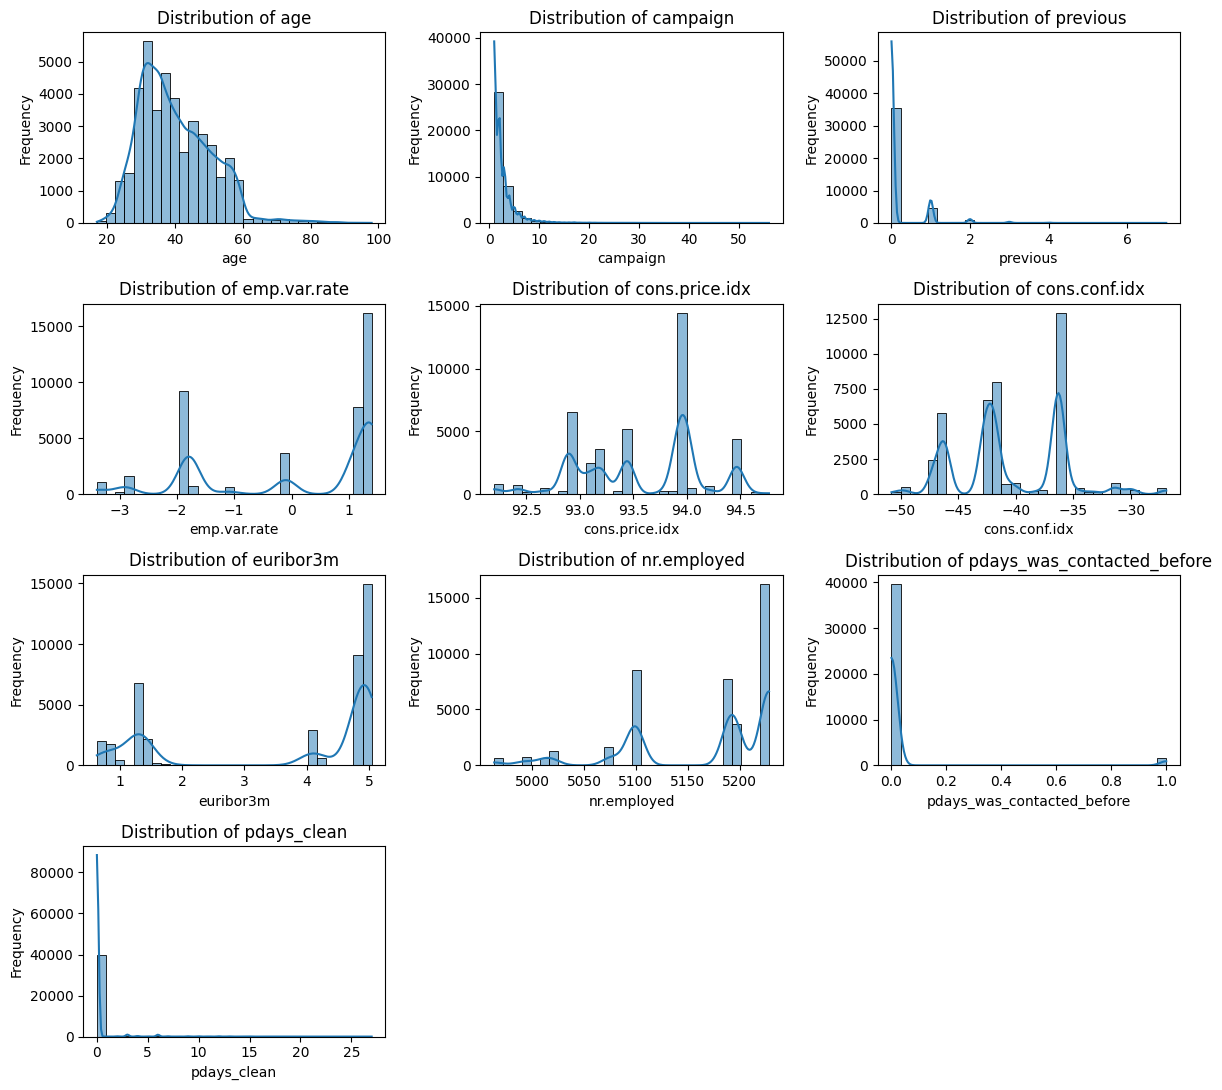

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = numeric_features[:10]
fig, axes = plt.subplots(4, 3, figsize=(12, 11))
axes = axes.flatten()

for idx, col in enumerate(features_to_plot):
    sns.histplot(X[col], bins=30, kde=True, ax=axes[idx],)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

for idx in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

feature_plan = pd.DataFrame({
    'decision': ['drop now', 'try dropping later', 'one-hot encode', 'scale numeric', 'target encoding'],
    'features': [
        features_to_drop_now,
        features_to_try_dropping_later,
        categorical_features,
        numeric_features,
        ['y -> no: 0, yes: 1'],
    ],
})

feature_plan


,decision,features
0,drop now,[duration]
1,try dropping later,"[loan, housing, day_of_week, marital, educatio..."
2,one-hot encode,"[job, marital, education, default, housing, lo..."
3,scale numeric,"[age, campaign, previous, emp.var.rate, cons.p..."
4,target encoding,"[y -> no: 0, yes: 1]"


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [15]:
# We stratify the split to ensure the same proportion of subscribers in both sets, which is important given the class imbalance.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21,
    stratify=y,
)


In [16]:
split_summary = pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [len(X_train), len(X_test)],
    'share_of_total': [len(X_train) / len(X), len(X_test) / len(X)],
    'subscription_rate': [y_train.mean(), y_test.mean()],
})

split_summary


,dataset,rows,share_of_total,subscription_rate
0,train,32950,0.79999,0.112656
1,test,8238,0.20001,0.112649


In [17]:
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')
print(f'Train positive class rate: {y_train.mean():.2%}')
print(f'Test positive class rate: {y_test.mean():.2%}')


Training set shape: (32950, 20)
Test set shape: (8238, 20)
Train positive class rate: 11.27%
Test positive class rate: 11.26%


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [18]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)


In [19]:
baseline_results = pd.DataFrame({
    'metric': ['accuracy', 'precision', 'recall'],
    'value': [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, baseline_pred, zero_division=0),
    ],
})

baseline_results


,metric,value
0,accuracy,0.887351
1,precision,0.000000
2,recall,0.000000


In [20]:
baseline_takeaway = (
    f"The baseline classifier always predicts the majority class, which is 'no'. "
    f"That produces {accuracy_score(y_test, baseline_pred):.2%} accuracy on the test set, "
    f"but it has {recall_score(y_test, baseline_pred, zero_division=0):.2%} recall for actual subscribers. "
    'A useful model should therefore do more than beat the baseline accuracy; it should also identify some of the positive cases.'
)

baseline_takeaway


"The baseline classifier always predicts the majority class, which is 'no'. That produces 88.74% accuracy on the test set, but it has 0.00% recall for actual subscribers. A useful model should therefore do more than beat the baseline accuracy; it should also identify some of the positive cases."

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [21]:
from sklearn.linear_model import LogisticRegression

# defined above for use in the pipeline, but we could also just do the transformations separately here if we wanted to.
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numeric_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
#     ]
# )


lg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=17, max_iter=1000)),
])
lg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### Problem 9: Score the Model

What is the accuracy of your model?

In [22]:
logistic_results = pd.DataFrame({
    'dataset': ['train', 'test'],
    'accuracy': [
        accuracy_score(y_train, lg.predict(X_train)),
        accuracy_score(y_test, lg.predict(X_test)),
    ],
    'precision': [
        precision_score(y_train, lg.predict(X_train), zero_division=0),
        precision_score(y_test, lg.predict(X_test), zero_division=0),
    ],
    'recall': [
        recall_score(y_train, lg.predict(X_train), zero_division=0),
        recall_score(y_test, lg.predict(X_test), zero_division=0),
    ],
})
logistic_results

,dataset,accuracy,precision,recall
0,train,0.899605,0.661342,0.223060
1,test,0.902646,0.683140,0.253233


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [23]:
from time import perf_counter

from sklearn.base import clone
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


In [24]:
comparison_models = {
    'Baseline (DummyClassifier)': clone(baseline_model),
    'Logistic Regression': clone(lg),
    'KNN': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier()),
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier()),
    ]),
    'SVM': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', SVC()),
    ]),
}

comparison_rows = []

for model_name, model in comparison_models.items():
    start_time = perf_counter()
    fitted_model = model.fit(X_train, y_train)
    fit_time = perf_counter() - start_time

    train_pred = fitted_model.predict(X_train)
    test_pred = fitted_model.predict(X_test)

    comparison_rows.append({
        'Model': model_name,
        'Fit Time (s)': fit_time,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Train Precision': precision_score(y_train, train_pred, zero_division=0),
        'Test Precision': precision_score(y_test, test_pred, zero_division=0),
        'Train Recall': recall_score(y_train, train_pred, zero_division=0),
        'Test Recall': recall_score(y_test, test_pred, zero_division=0),
    })

comparison_results = pd.DataFrame(comparison_rows)


In [25]:
comparison_results = comparison_results.sort_values(['Test Recall', 'Test Precision'], ascending=[False, False]).reset_index(drop=True)
comparison_results.style.format({
    'Fit Time (s)': '{:.4f}',
    'Train Accuracy': '{:.3f}',
    'Test Accuracy': '{:.3f}',
    'Train Precision': '{:.3f}',
    'Test Precision': '{:.3f}',
    'Train Recall': '{:.3f}',
    'Test Recall': '{:.3f}',
})


,Model,Fit Time (s),Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall
0,Decision Tree,0.1726,0.994,0.841,0.998,0.315,0.952,0.349
1,KNN,0.0265,0.914,0.892,0.714,0.537,0.388,0.319
2,SVM,25.2830,0.904,0.904,0.699,0.674,0.265,0.280
3,Logistic Regression,0.0646,0.900,0.903,0.661,0.683,0.223,0.253
4,Baseline (DummyClassifier),0.0007,0.887,0.887,0.000,0.000,0.000,0.000


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [26]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures


In [27]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
}

# Because the business goal is to capture more potential subscribers,
# we refit on recall while still tracking accuracy and precision.
refit_metric = 'recall'


In [28]:
poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

tuned_models = {
    'Logistic Regression': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(max_iter=1000)),
        ]),
        'param_grid': {
            'model__solver': ['liblinear'],
            'model__C': [0.001, 0.002],
            'model__class_weight': ['balanced'],
        },
    },
    'Polynomial Logistic Regression': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', poly_preprocessor),
            ('model', LogisticRegression(max_iter=1000)),
        ]),
        'param_grid': {
            'model__solver': ['liblinear'],
            'model__C': [0.001, 0.002],
            'model__class_weight': ['balanced'],
        },
    },
    'KNN': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', KNeighborsClassifier()),
        ]),
        'param_grid': {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan'],
        },
    },
    'Decision Tree': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', DecisionTreeClassifier(random_state=17)),
        ]),
        'param_grid': {
            'model__max_depth': [None, 3, 5, 7],
            'model__min_samples_split': [2, 10, 20],
            'model__min_samples_leaf': [8,  10, 12],
            'model__class_weight': ['balanced'],
        },
    },
    'SVM': {
        'pipeline': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', SVC()),
        ]),
        'param_grid': [
            {
                'model__kernel': ['rbf'],
                'model__C': [1, 1.2],
                'model__gamma': ['scale'],
                'model__class_weight': ['balanced'],
            },
        ],
    },
}


In [29]:
grid_searches = {}
grid_search_summary_rows = []

for model_name, config in tuned_models.items():
    search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        scoring=scoring_metrics,
        refit=refit_metric,
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    grid_searches[model_name] = search

    best_model = search.best_estimator_
    test_pred = best_model.predict(X_test)

    grid_search_summary_rows.append({
        'Model': model_name,
        'Best Params': search.best_params_,
        'Best CV Accuracy': search.cv_results_['mean_test_accuracy'][search.best_index_],
        'Best CV Precision': search.cv_results_['mean_test_precision'][search.best_index_],
        'Best CV Recall': search.cv_results_['mean_test_recall'][search.best_index_],
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Test Precision': precision_score(y_test, test_pred, zero_division=0),
        'Test Recall': recall_score(y_test, test_pred, zero_division=0),
    })


In [30]:
grid_search_results = pd.DataFrame(grid_search_summary_rows).sort_values(['Best CV Recall', 'Best CV Precision'], ascending=[False, False]).reset_index(drop=True)
grid_search_results.style.format({
    'Best CV Accuracy': '{:.3f}',
    'Best CV Precision': '{:.3f}',
    'Best CV Recall': '{:.3f}',
    'Test Accuracy': '{:.3f}',
    'Test Precision': '{:.3f}',
    'Test Recall': '{:.3f}',
})


,Model,Best Params,Best CV Accuracy,Best CV Precision,Best CV Recall,Test Accuracy,Test Precision,Test Recall
0,Logistic Regression,"{'model__C': 0.001, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}",0.779,0.291,0.668,0.789,0.307,0.692
1,Polynomial Logistic Regression,"{'model__C': 0.001, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}",0.783,0.295,0.666,0.791,0.308,0.688
2,Decision Tree,"{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 12, 'model__min_samples_split': 2}",0.731,0.240,0.638,0.732,0.243,0.652
3,SVM,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'rbf'}",0.844,0.381,0.609,0.850,0.397,0.638
4,KNN,"{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}",0.871,0.405,0.306,0.876,0.436,0.337


In [31]:
best_tuned_model_name = grid_search_results.loc[0, 'Model']
best_tuned_search = grid_searches[best_tuned_model_name]

best_tuned_model_summary = pd.Series({
    'Selected model': best_tuned_model_name,
    'Refit metric': refit_metric,
    'Best parameters': best_tuned_search.best_params_,
    'Cross-validated recall': best_tuned_search.cv_results_['mean_test_recall'][best_tuned_search.best_index_],
    'Cross-validated precision': best_tuned_search.cv_results_['mean_test_precision'][best_tuned_search.best_index_],
    'Cross-validated accuracy': best_tuned_search.cv_results_['mean_test_accuracy'][best_tuned_search.best_index_],
    'Test recall': grid_search_results.loc[0, 'Test Recall'],
    'Test precision': grid_search_results.loc[0, 'Test Precision'],
    'Test accuracy': grid_search_results.loc[0, 'Test Accuracy'],
})

best_tuned_model_summary


Selected model                                             Logistic Regression
Refit metric                                                            recall
Best parameters              {'model__C': 0.001, 'model__class_weight': 'ba...
Cross-validated recall                                                 0.66838
Cross-validated precision                                             0.291092
Cross-validated accuracy                                              0.778968
Test recall                                                            0.69181
Test precision                                                         0.30703
Test accuracy                                                         0.789391
dtype: object

In [32]:
grid_search_results[['Model', 'Test Accuracy', 'Test Precision', 'Test Recall']]


,Model,Test Accuracy,Test Precision,Test Recall
0,Logistic Regression,0.789391,0.307030,0.691810
1,Polynomial Logistic Regression,0.790726,0.307915,0.687500
2,Decision Tree,0.731852,0.242874,0.651940
3,SVM,0.849964,0.396783,0.637931
4,KNN,0.876184,0.435933,0.337284


In [33]:
low_signal_features_available = [feature for feature in features_to_try_dropping_later if feature in X_train.columns]
best_tuned_model = best_tuned_search.best_estimator_

X_train_reduced = X_train.drop(columns=low_signal_features_available).copy()
X_test_reduced = X_test.drop(columns=low_signal_features_available).copy()

reduced_categorical_features = X_train_reduced.select_dtypes(include=['object', 'string']).columns.tolist()
reduced_numeric_features = X_train_reduced.select_dtypes(include='number').columns.tolist()

def build_pipeline_for_feature_set(model_name, numeric_cols, categorical_cols):
    standard_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ]
    )

    poly_preprocessor_local = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                ('scaler', StandardScaler()),
            ]), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ]
    )

    if model_name == 'Logistic Regression':
        return Pipeline(steps=[('preprocessor', standard_preprocessor), ('model', LogisticRegression(max_iter=1000))])
    if model_name == 'Polynomial Logistic Regression':
        return Pipeline(steps=[('preprocessor', poly_preprocessor_local), ('model', LogisticRegression(max_iter=1000))])
    if model_name == 'KNN':
        return Pipeline(steps=[('preprocessor', standard_preprocessor), ('model', KNeighborsClassifier())])
    if model_name == 'Decision Tree':
        return Pipeline(steps=[('preprocessor', standard_preprocessor), ('model', DecisionTreeClassifier(random_state=17))])
    if model_name == 'SVM':
        return Pipeline(steps=[('preprocessor', standard_preprocessor), ('model', SVC())])
    raise ValueError(f'Unsupported model: {model_name}')

reduced_best_model = build_pipeline_for_feature_set(
    best_tuned_model_name,
    reduced_numeric_features,
    reduced_categorical_features,
)
reduced_best_model.set_params(**best_tuned_search.best_params_)
reduced_best_model.fit(X_train_reduced, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [34]:
feature_drop_comparison = pd.DataFrame([
    {
        'Feature Set': 'Full feature set',
        'Dropped Features': 'None',
        'Train Accuracy': accuracy_score(y_train, best_tuned_model.predict(X_train)),
        'Test Accuracy': accuracy_score(y_test, best_tuned_model.predict(X_test)),
        'Train Precision': precision_score(y_train, best_tuned_model.predict(X_train), zero_division=0),
        'Test Precision': precision_score(y_test, best_tuned_model.predict(X_test), zero_division=0),
        'Train Recall': recall_score(y_train, best_tuned_model.predict(X_train), zero_division=0),
        'Test Recall': recall_score(y_test, best_tuned_model.predict(X_test), zero_division=0),
    },
    {
        'Feature Set': 'Reduced feature set',
        'Dropped Features': ', '.join(low_signal_features_available),
        'Train Accuracy': accuracy_score(y_train, reduced_best_model.predict(X_train_reduced)),
        'Test Accuracy': accuracy_score(y_test, reduced_best_model.predict(X_test_reduced)),
        'Train Precision': precision_score(y_train, reduced_best_model.predict(X_train_reduced), zero_division=0),
        'Test Precision': precision_score(y_test, reduced_best_model.predict(X_test_reduced), zero_division=0),
        'Train Recall': recall_score(y_train, reduced_best_model.predict(X_train_reduced), zero_division=0),
        'Test Recall': recall_score(y_test, reduced_best_model.predict(X_test_reduced), zero_division=0),
    },
])

feature_drop_comparison.style.format({
    'Train Accuracy': '{:.3f}',
    'Test Accuracy': '{:.3f}',
    'Train Precision': '{:.3f}',
    'Test Precision': '{:.3f}',
    'Train Recall': '{:.3f}',
    'Test Recall': '{:.3f}',
})


,Feature Set,Dropped Features,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall
0,Full feature set,None,0.785,0.789,0.297,0.307,0.662,0.692
1,Reduced feature set,"loan, housing, day_of_week, marital, education, campaign",0.775,0.777,0.286,0.294,0.672,0.696


In [35]:
feature_drop_impact = pd.Series({
    'Best tuned model': best_tuned_model_name,
    'Features tested for removal': ', '.join(low_signal_features_available),
    'Change in test accuracy': feature_drop_comparison.loc[1, 'Test Accuracy'] - feature_drop_comparison.loc[0, 'Test Accuracy'],
    'Change in test precision': feature_drop_comparison.loc[1, 'Test Precision'] - feature_drop_comparison.loc[0, 'Test Precision'],
    'Change in test recall': feature_drop_comparison.loc[1, 'Test Recall'] - feature_drop_comparison.loc[0, 'Test Recall'],
})

feature_drop_impact


Best tuned model                                             Logistic Regression
Features tested for removal    loan, housing, day_of_week, marital, education...
Change in test accuracy                                                -0.012017
Change in test precision                                               -0.013127
Change in test recall                                                    0.00431
dtype: object

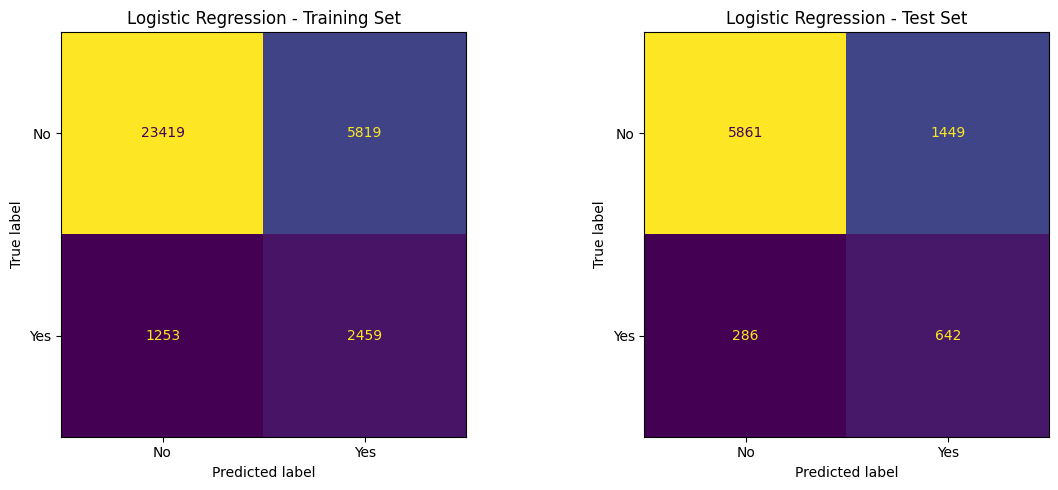

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

best_tuned_model = best_tuned_search.best_estimator_
train_pred_best = best_tuned_model.predict(X_train)
test_pred_best = best_tuned_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_train, train_pred_best),
    display_labels=['No', 'Yes']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_tuned_model_name} - Training Set')

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, test_pred_best),
    display_labels=['No', 'Yes']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'{best_tuned_model_name} - Test Set')

plt.tight_layout()
plt.show()


In [37]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred_best).ravel()
predicted_yes = tp + fp
actual_yes = tp + fn
test_set_size = len(y_test)
baseline_success_rate = actual_yes / test_set_size
expected_random_successes = predicted_yes * baseline_success_rate

successful_calls_statement = (
    f"If the bank used {best_tuned_model_name} on the test set and only called the clients predicted as likely subscribers, "
    f"it would place {predicted_yes} targeted calls and about {tp} of those calls would be successful. "
    f"That implies a success rate of {tp / predicted_yes:.2%} among the targeted calls, while the model captures {tp / actual_yes:.2%} of all actual subscribers in the test set. "
    f"If the bank instead chose the same number of clients at random, it would expect about {expected_random_successes:.0f} successful calls, based on the overall test-set subscription rate of {baseline_success_rate:.2%}"
    f" , which means that the success rate is improved by a factor {tp/expected_random_successes:.1f}."
)

successful_calls_statement


'If the bank used Logistic Regression on the test set and only called the clients predicted as likely subscribers, it would place 2091 targeted calls and about 642 of those calls would be successful. That implies a success rate of 30.70% among the targeted calls, while the model captures 69.18% of all actual subscribers in the test set. If the bank instead chose the same number of clients at random, it would expect about 236 successful calls, based on the overall test-set subscription rate of 11.26% , which means that the success rate is improved by a factor 2.7.'

##### Questions